<a href="https://colab.research.google.com/github/AChierici84/ProfessionAI/blob/main/Riconoscimento_animali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Riconoscimento di animali per auto a guida autonoma
VisionTech Solutions vuole sviluppare un sistema di riconoscimento automatico delle immagini per distinguere tra veicoli e animali, con l'obiettivo di ottimizzare le operazioni di monitoraggio della fauna nelle aree urbane, evitando incidenti stradali e proteggendo sia gli animali che i veicoli.

VisionTech Solutions collabora con le amministrazioni comunali per implementare un sistema di monitoraggio in tempo reale nelle città, utilizzando telecamere installate lungo le strade per identificare e classificare veicoli e animali. Questo sistema aiuterà a prevenire incidenti stradali causati dall'attraversamento improvviso di animali, avvisando i guidatori tramite segnali stradali elettronici.

Benefici:

1.   **Automazione dei Processi:**
Riduzione del tempo e delle risorse per monitorare manualmente le aree urbane.
        Rilevamento automatico e in tempo reale di animali e veicoli.
2.    **Aumento della Precisione:** Utilizzo di una rete neurale convoluzionale (CNN) per garantire alta precisione nella classificazione delle immagini.
        Minimizzazione degli errori umani.
3.   **Efficienza Operativa:**
      Processamento rapido e accurato di grandi volumi di dati, migliorando la risposta agli eventi.
        Maggiore sicurezza per i cittadini e riduzione dei danni ai veicoli.
2.   **Applicazioni Multiple:** Sorveglianza e monitoraggio del traffico.
        Analisi del comportamento animale nelle aree urbane.
        Utilizzo dei dati per migliorare le politiche di sicurezza stradale.

Dettagli del Progetto:


1. **Dataset:**
Utilizzo del dataset CIFAR, contenente migliaia di immagini etichettate in varie categorie, inclusi veicoli e animali.
2. **Algoritmo:**
Implementazione di una rete neurale convoluzionale (CNN) per l'analisi e la classificazione delle immagini.
3.  **Output:**
Il sistema classificherà correttamente ogni immagine come veicolo o animale.

**Valutazione del Modello:**

*   **Accuratezza:** Proporzione di immagini classificate correttamente rispetto al totale
*   **Precisione:** Qualità delle predizioni positive, indicando la proporzione di immagini correttamente identificate.

**Analisi dei Risultati:**

*   Identificazione di eventuali pattern di errore.
*   Valutazione delle categorie di immagini confuse sistematicamente.
*   Esame delle immagini errate e riflessione su possibili migliorie al modello.

**Risultato Finale:**

*   Presentazione completa della rete neurale convoluzionale e delle sue capacità di discriminazione tra veicoli e animali.
*   Discussione dettagliata delle metriche utilizzate e un'analisi critica delle prestazioni e limitazioni del modello.

Questo progetto fornirà a VisionTech Solutions un sistema efficace per migliorare la sicurezza stradale e la gestione della fauna nelle aree urbane, dimostrando le competenze pratiche nell'applicazione del machine learning al riconoscimento delle immagini.





In [ ]:
# No warn
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
# Imports
import numpy as np
import math
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models,regularizers
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset

Il dataset CIFAR 10 è un dataset usato in Computer Vision per il riconoscimento di oggetti. E' costituito da immagini a colori di piccole dimensioni (32x32) contenenti ciascuna un oggetto appartenente a 10 classi:

*   airplane
*   automobile
*   bird
*   cat
*   deer
*   dog
*   frog
*   horse
*   ship
*   truck

Aeroplani, automobili, navi e camion appartengono alla sovra-calsse dei veicoli.
Uccelli, gatti, cervi, cani, rane, cavalli appartengono alla classe degi animali.

Quindi, lo stesso dataset può essere usato anche per effettuare classificazione binaria su animali / mezzi di trasporto che si adatta ai nostri scopi.

In [ ]:
# Split dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Carichiamo il dataset che risulta già essere suddiviso in train e test.

In [ ]:
X_train.shape

(50000, 32, 32, 3)

Nel train set abbiamo 50000 immagini 32x32 a 3 canali ciascuna (R,G,B).

In [ ]:
X_test.shape

(10000, 32, 32, 3)

Nel test set abbiamo 10000 immagini 32x32 a 3 canali ciascuna (R,G,B).

In [ ]:
# Normalizza le immagini (valori 0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

Normalizzo le immagini  scalando i valori tra 0-1 per facilitare l'apprendimento del modello.

Visualizziamo un sample del target.

In [ ]:
y_train[:10]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3]], dtype=uint8)

Come target abbiamo le nostre 10 classi numerate. Che dovranno essere riportate invece nelle due categorie: dato che il nostro obbiettivo è riconoscere gli animali, etichetteremo come 1 gli animali e come 0 tutte le categorie dei mezzi.

In [ ]:
original_classes_lables=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
original_classes={0:"airplane", 1:"automobile", 2:"bird", 3:"cat", 4:"deer", 5:"dog", 6:"frog", 7:"horse", 8:"ship", 9:"truck"}
animals_binary={0:"vehicle", 1:"animal"}
animals_binary_labels=["Veicoli", "Animali"]
mapping_classes_to_binary={0:0, 1:0, 2:1, 3:1, 4:1, 5:1, 6:1, 7:1, 8:0, 9:0}

#sostituisco le classi secondo il mapping
y_train_binary=np.vectorize(mapping_classes_to_binary.get)(y_train)
y_test_binary=np.vectorize(mapping_classes_to_binary.get)(y_test)
y_train_binary[:10]

array([[1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1]])

Convertiamo le due classi animali/veicoli in rappresentazione One Hot Encoding.

In [ ]:
y_train_binary=tf.keras.utils.to_categorical(y_train_binary, num_classes=2)
y_test_binary=tf.keras.utils.to_categorical(y_test_binary, num_classes=2)

y_train_binary[:10]

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

I valori che hanno un 1 nella prima colonna sono veicoli, quelli che hanno un 1 nella seconda colonna sono animali.

Di seguito si possono vedere le prime 10 immagine con label originaria e la versione binaria.




In [ ]:
def plot_sample_orig_binary(classes, binary_classes, X, y, y_binary, SAMPLE_SIZE=20):
    """
    Funzione per plottare immagini di esempio e mettere a confronto
    la label di origine e quella nella classificazione binaria.
    """
    # Calcolo il numero di colonne e righe
    cols = int(math.sqrt(SAMPLE_SIZE))
    rows = int(math.ceil(SAMPLE_SIZE / cols))

    plt.figure(figsize=(12, 6))
    for i in range(SAMPLE_SIZE):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i])
        orig_label = classes[y[i].item()]
        binary_label = binary_classes[np.argmax(y_binary[i])]
        plt.title(f"{orig_label}\n({binary_label})", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

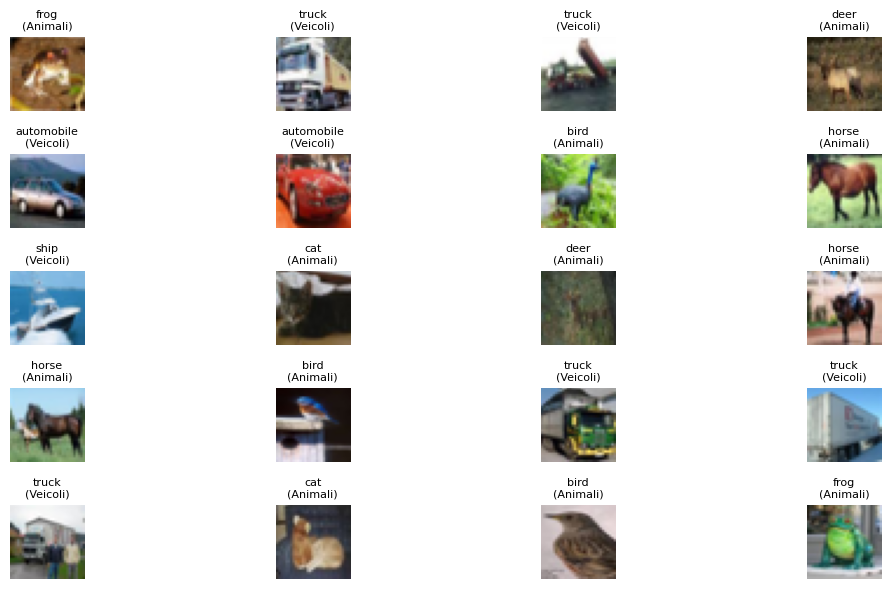

In [ ]:
plot_sample_orig_binary(original_classes_lables,animals_binary_labels,X_train,y_train,y_train_binary)

Valutiamo il bilanciamento dopo la conversione.

In [ ]:
# conteggio con le classi binarie
classes_counts = {"vehicle": 0, "animal": 0}

for e in y_train_binary:
    if np.argmax(e) == 0:
        classes_counts["vehicle"] += 1
    else:
        classes_counts["animal"] += 1

print(classes_counts)

{'vehicle': 20000, 'animal': 30000}


Il dataset è un po' sbilanciato sugli animali, questo è comprensbile dato che il CIFER 10 ha 6 categorie di animali e solo 4 di veicoli. Una rete neurale CNN dovrebbe poter gestire lo sbilanciamento, ma possiamo valutare anche se utilizzare una politica di gestione dei pesi. Passiamo alla realizzazione del modello.

##Rete neurale convoluzionale (CNN)

Come richiesto verrà realizzata una rete neurale convoluzionale per analizzare le immagini, estrarne le features principali e classificarle come "animali" o "veicoli."


Costruisco il modello con sintassi sequenziale.

In [ ]:
clear_session()
model = models.Sequential([
    layers.InputLayer(input_shape=(32, 32, 3)),

    # 1° convoluzione
    layers.Conv2D(32, (3,3), activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # 2° convoluzione
    layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    # Dense con Dropout
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.6),

    # Output 2 classi binarie
    layers.Dense(2, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,082 (211.26 KB)

 Trainable params: 53,890 (210.51 KB)

 Non-trainable params: 192 (768.00 B)

La rete è costituita da:

*   un Input Layer che prende in ingresso immagini 32x32x3 canali RGB
*   Due strati di convoluzione con n° di filtri crescente (32,64) e di grandezza fissa 3x3 e stride pari a 1 (default) date le dimensioni ridotte dell'immagine.
*  Nei primi due strati convoluzionali viene effettuato una batch normalization per stabilizzare e accelerare il training normalizzando gli input di ogni layer.
*  Dopo l'Ultima convoluzione il GlobalAveragePooling2D trasforma il tensore in un vettore piatto calcolando  il raggruppamento medio sulle dimensioni spaziali fino a quando ciascuna di esse diventa unitaria. Il vettore risultante costituirà l'input per la rete seguente fully connected.  
*  Quindi troviamo un primo strato denso con 512 nodi e un ultimo strato di 2 nodi per arrivare alla classificazione binaria con una funzione di attivazione **Softmax** che fornisce in output la probabilità di uscita per ciascuna categoria (Veicoli, Animali).  

* Tra i due strati densi è stato inserito uno strato di Dropout per prevenire l'overfitting, disattivando randomicamente una frazione dei neuroni durante il training.  

* I due nodi di convoluzione e lo strato denso hanno una regolarizzazione L2 del kernel che evita che i pesi diventino troppo grandi, riducendo l'overfitting e aiutando così il modello a generalizzare meglio.
 Senza L2 i filtri a volte tendono ad essere un po' "estremi" per adattarsi perfettamente al training set. Grazie all'L2 i filtri rimangono più soft e il modello non esagera con valori troppo grandi.



Compiliamo il modello.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Per la comilazione utilizziamo Adam come optimizer, una loss 'categorical_crossentropy' dato che abbiamo due classi in uscita con One Hot Encoding e come metrica aggiuntiva l'accuracy che ci permetterà di valutare meglio la rete oltre alla Loss.

Predisponiamo le callback necessarie al modello.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',           # se validation loss non cambia
    patience=7,                   # aspetta 7 epoche senza miglioramento
    restore_best_weights=True     # ripristina i pesi migliori
    )

# Callback per ridurre il learning rate quando la validazione si stabilizza
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',      # se validation loss non cambia
    factor=0.5,              # riduce il LR della metà
    patience=5,              # aspetta 5 epoche senza miglioramento
    min_lr=1e-6,             # Learning rate minimo
    verbose=1
)


Testiamo un addestramento base per 15 epoche per valutare se la rete sviluppata è in grado di apprendere dalle immagini.

In [ ]:
history = model.fit(
    X_train, y_train_binary,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test_binary),
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9625 - loss: 0.1133 - val_accuracy: 0.9455 - val_loss: 0.1638 - learning_rate: 6.2500e-05
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9631 - loss: 0.1108 - val_accuracy: 0.9434 - val_loss: 0.1661 - learning_rate: 6.2500e-05
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9653 - loss: 0.1070 - val_accuracy: 0.9444 - val_loss: 0.1649 - learning_rate: 6.2500e-05
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9650 - loss: 0.1068 - val_accuracy: 0.9462 - val_loss: 0.1581 - learning_rate: 6.2500e-05
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9649 - loss: 0.1065 - val_accuracy: 0.9461 - val_loss: 0.1609 - learning_rate: 6.2500e-05
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9657 - loss: 0.1045 - val_accuracy: 0.9450 - val_loss: 0.1634 - learning_rate: 6.2500e-05
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 

L’accuracy di training e validazione si mantengono vicine il che significa un certo equilibrio tra apprendimento e generalizzazione.

La loss di validazione è stabile intorno a 0.16, quindi il modello è arrivato al suo massimo.

Dopo la riduzione del learning rate non c’è un miglioramento evidente:
la val_loss rimane praticamente identica. Questo indica che ha raggiunto il limite della sua capacità per questa configurazione e dataset.

Non viene riscontrata divergenza tra train e validation.
Nessun segno di memorizzazione, il modello sembra generalizzare bene.
Dopo 7/8 epoche, la curva si è completamente stabilizzata.

Salviamo il modello e l'history associata.

In [ ]:
model.save('model.keras')
np.save('history.npy', history.history)

Carichiamo il modello e la history se già presenti

In [ ]:
model.load_weights('model.keras')
history = np.load('history.npy', allow_pickle='TRUE').item()

## Valutazione del Modello

Definiamo le funzioni necessarie alla valutazione del modello.

In [ ]:
def plot_history(history):
  """
  Funzione per plottare l'andamento dell'addestramento
  del modello.
  Input: history della rete
  """
  plt.figure(figsize=(12,4))
  plt.subplot(1,3,1)
  plt.plot(history['loss'],label='loss')
  plt.plot(history['val_loss'],label='val_loss')
  plt.ylim([0,1])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss Training and Validation set')
  plt.legend()
  plt.subplot(1,3,2)
  plt.plot(history['accuracy'],label='accuracy')
  plt.plot(history['val_accuracy'],label='val_accuracy')
  plt.ylim([0,1])
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.title('Accuracy Training and Validation set')
  # --- LEARNING RATE ---
  if 'learning_rate' in history:
        plt.subplot(1,3,3)
        plt.plot(history['learning_rate'], label='learning_rate', color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.legend()
        plt.title('Learning Rate Schedule')
  plt.tight_layout()
  plt.legend()
  plt.show()

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, title=None, cmap=plt.cm.Blues):
  """
  Funzione per plottare la matrice di confusione.
  Input:
    y_true: valori target
    y_pred: predizioni del modello
    classes: nomi delle classi
    title: titolo della matrice
  """
  cm = confusion_matrix(y_true, y_pred)
  sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=classes, yticklabels=classes)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  if title:
    plt.title(title)
  plt.show()

In [ ]:
def plot_errors(errors, classes, X_test, y_true,y_pred, SAMPLE_SIZE = 20):
  """
  Funzione per plottare le immagini sbagliate.
  Input:
    errors: indici delle immagini sbagliate
    classes: nomi delle classi
    X_test: immagini di test
    y_true: valori target
    y_pred: predizioni del modello
  """
  SAMPLE_SIZE = 20
  sample_errors = errors[:SAMPLE_SIZE]

   # Calcolo il numero di colonne e righe
  cols = int(math.sqrt(SAMPLE_SIZE))
  rows = int(math.ceil(SAMPLE_SIZE / cols))

  plt.figure(figsize=(12,6))
  for i, idx in enumerate(sample_errors):
      plt.subplot(rows, cols, i+1)
      plt.imshow(X_test[idx])
      plt.title(f"Immagine {idx}\nTrue: {classes[y_true[idx]]}\nPred: {classes[y_pred[idx]]}", fontsize=8 )
      plt.axis("off")
  plt.tight_layout()
  plt.show()

Visualizziamo le curve di Loss, Accuracy e Learing rate per il modello realizzato:

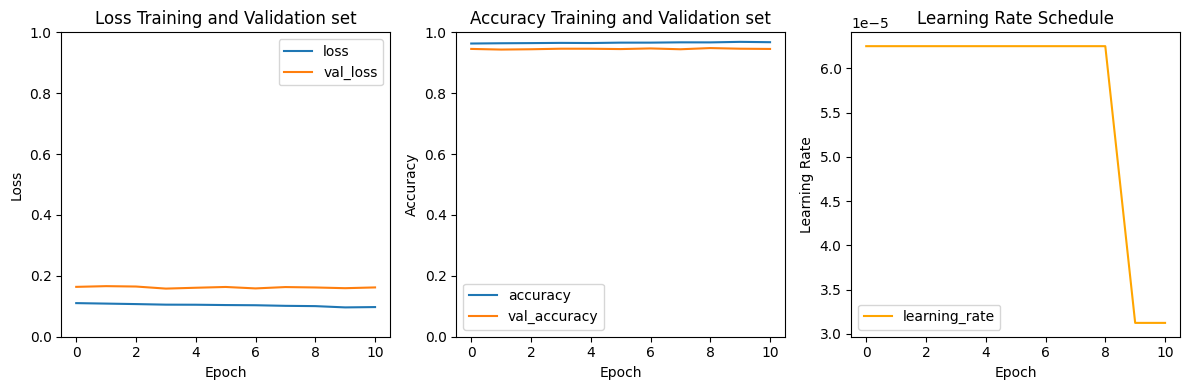

In [ ]:
plot_history(history)

La loss del train e test set vanno di pari passo e si mantengono entrambe poco sopra 0.15, un ottimo valore.
Anche le accuracy sono molto vicine tra loro, sempre intorno al 96/93%.
La LR viene abbassata dalla callback ReduceLROnPlateau alla 9° epoca per tentare un miglioramento, l'accuracy tuttavia rimane costante, segno che si è già giunti alla convergenza per questa rete e questo dataset.

Valutiamo le performance sulle immagini del test set.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_binary, verbose=2)
print(f"Test accuracy: {test_acc:.3f}")

313/313 - 1s - 2ms/step - accuracy: 0.9462 - loss: 0.1581
Test accuracy: 0.946


Abbiamo raggiunto un accuracy del 94,6% e una loss di 0.1581.

Valutiamo ora recall e precision.

In [ ]:
y_true = y_test_binary.argmax(axis=1)
y_pred = model.predict(X_test).argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=animals_binary_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

     Veicoli       0.93      0.93      0.93      4000
     Animali       0.95      0.96      0.96      6000

    accuracy                           0.95     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.95      0.95      0.95     10000



In media i valori di precision e recall sono leggermente più bassi per i veicoli e migliori invece per gli Animali, il che è spiegabile con lo sbilacimento nelle due classi, anche se dovendo noi inviduare la comparsa di animali sulla carreggiata come primo scopo di questa rete ci interessa soprattutto avere una buona recall sugli animali cu cui si raggiunge un buon valore di 0.96.

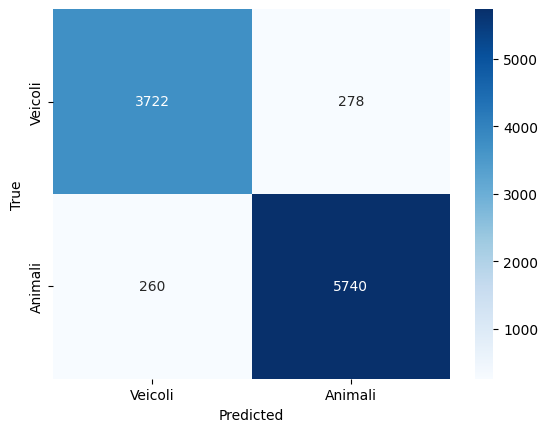

In [ ]:
plot_confusion_matrix(y_true, y_pred, classes=animals_binary_labels)

Valutando graficamente la matrice di confusione notiamo anche da qui prestazioni peggiori sui veicoli e migliori invece sugli animali.  

Valuto le immagini che non vengono correttamente identificate.

Errori 538 su 10000 immagini (5.38%)


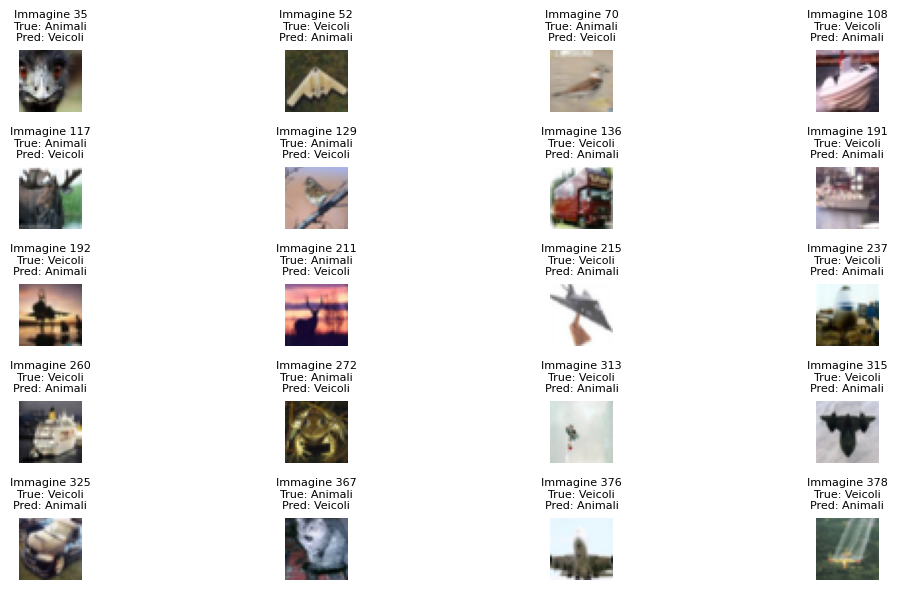

In [ ]:
errors = np.where(y_pred != y_true)[0]

print(f"Errori {len(errors)} su {len(y_true)} immagini ({(len(errors)*100)/len(y_true)}%)")
plot_errors(errors, animals_binary_labels, X_test, y_true, y_pred)


Gli errori sono soprattutto nella confusione tra aerei e uccelli o quando nella immagini trovaimo forme triangolari (becchi scambiati per fusoliera, ali di aeromobili per quelle di volatili) . In altri casi si tratta di immagini molto scure o molto chiare o con l'oggetto non in primo piano (molto piccolo o sfumato) o anche di colori molto simili allo sfondo. Forse in questi casi aumentando il contrasto dell'immagine otteremmo risultati migliori. Per alcuni sample comunque anche un occhio umano avrebbe difficoltà a distinguerli.

##Transfer learning

Il nostro modello è buono, ma valutiamo in ultima battuta se usare il Trasfer Learning potrebbe portare vantaggi. Il problema più grande è che le reti trainate su IMAGENET hanno come riferimento immagini molto più grandi di quelle del dataset CIFAR 10 (224,224) contro (32,32). Se proviamo ad allargare le immagini correnti ci rendiamo conto facilmente che la definizione rimane molto bassa, difficilmente i pesi calcolati su immagini  7 volte più grandi daranno ottimi risultati. Esiste però la possibilità già sondata da alcuni ricercatori di utilizzare la RESNET20 con il dataset CIFAR 10 , in questo caso è stato preso il solo modello della rete RESNET20 senza pesi associati ad IMAGE.NET ed è stato rifatto il training utilizzando la CIFAR 10. Ovviamente nel nostro caso abbiamo un problema diverso, quindi dovremo ridefinire la rete perchè abbiamo una classificazione Aniamli/Veicoli, non sulle dieci classi di oggetti.

Carichiamo da Tensorflow il modello base della ResNet20 modificando i parametri di input con quelli delle nostre immagini e aggiungendo i layer mancanti per fare Fine tuning sul nostro problema specifico.

In [ ]:
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights=None,
    input_shape=(32, 32, 3),
    pooling='avg'
)

In questo caso azzeriamo i pesi per non portarci dietro i pesi di Imagenet che sono relativi a immagini troppo grandi.

Aggiungiamo quindi, con sintassi funzionale i layer ricalcando la parte finale della nsotra rete CNN precedente.

In [ ]:
x = layers.Dense(512, activation='relu')(base_model.output)
x = layers.Dropout(0.6)(x)
output = layers.Dense(2, activation='softmax')(x)
transfer_model = tf.keras.Model(inputs=base_model.input, outputs=output)

transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │          0 │ conv2_block1_pre… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 10, 10,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 8, 256) │          0 │ conv2_block1_0_c

 Total params: 24,614,914 (93.90 MB)

 Trainable params: 24,569,474 (93.73 MB)

 Non-trainable params: 45,440 (177.50 KB)

In questo modo abbiamo ottenuto un modello molto più complesso che contiene 24 milioni di neuroni. Compiliamo il modello.

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Lanciamo il fit su dieci epoche usando le call back precedentemente definite.

In [ ]:
transfer_history = transfer_model.fit(
    X_train, y_train_binary,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_binary),
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9866 - loss: 0.0370 - val_accuracy: 0.9371 - val_loss: 0.2812 - learning_rate: 2.5000e-04
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9922 - loss: 0.0224 - val_accuracy: 0.9372 - val_loss: 0.3118 - learning_rate: 2.5000e-04
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9929 - loss: 0.0202 - val_accuracy: 0.9355 - val_loss: 0.3509 - learning_rate: 2.5000e-04
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9924 - loss: 0.0200 - val_accuracy: 0.9356 - val_loss: 0.3737 - learning_rate: 2.5000e-04
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9950 - loss: 0.0137 - val_accuracy: 0.9357 - val_loss: 0.3518 - learning_rate: 2.5000e-04
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9797 - loss: 0.0589
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - ac

Rispetto al  modello precedente il modelo RESNET raggiunge accuracy sul training molto più alte, ma non si riflettono su prestazioni altrettando buone sul set di validazione che raggiunge al massimo il 0,94. In ogni caso un buon risultato su questo dataset.
La val_loss rimane inoltre molto più elevata della rete precedente.

Salviamo il modello.

In [ ]:
transfer_model.save('transfer_model.keras')
np.save('transfer_history.npy', transfer_history.history)

Carichiamo il modello salvato.

In [ ]:
transfer_model.load_weights('transfer_model.keras')
transfer_history = np.load('transfer_history.npy', allow_pickle='TRUE').item()

Valutiamo la train history del modello risultante.

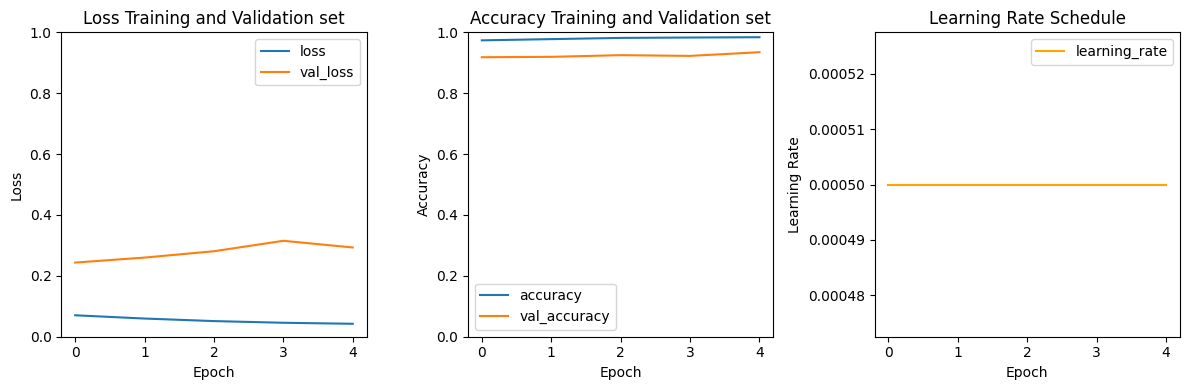

In [ ]:
plot_history(transfer_history)

Si può notare come la validation loss rimanga molto più alta rispetto al modello precedente, l'accuracy è più alta per il training set, ma rimane allo stesso livello sul test set.

In [ ]:
test_loss, test_acc = transfer_model.evaluate(X_test, y_test_binary, verbose=2)
print(f"Test accuracy: {test_acc:.3f}")

313/313 - 2s - 7ms/step - accuracy: 0.9371 - loss: 0.2812
Test accuracy: 0.937


Con questo modello otteniamo un accuracy media di 93.7%  e una loss di 0.28

Valutiamo ora il classification report.

In [ ]:
y_true_transfer = y_test_binary.argmax(axis=1)
y_pred_transfer = transfer_model.predict(X_test).argmax(axis=1)

print(classification_report(y_true_transfer, y_pred_transfer, target_names=animals_binary_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

     Veicoli       0.94      0.90      0.92      4000
     Animali       0.94      0.96      0.95      6000

    accuracy                           0.94     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.94      0.94     10000



L'accuracy in media è leggermente più bassa del modello precedente. La recall sugli animali risulta identica con uno 0.96 mentre la RESNET perde recall sui veicoli, attestandosi su uno 0.9.  Migliore la precision sui veicoli, peggiore quella sugli animali, ma comunque in linea col valore della rete precedente.

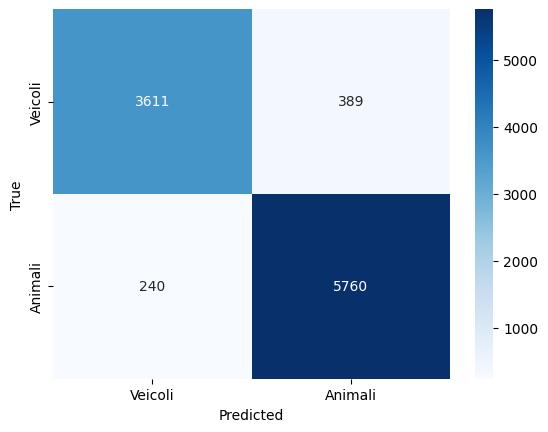

In [ ]:
plot_confusion_matrix(y_true_transfer, y_pred_transfer, classes=animals_binary_labels)

Anche da questa matrice di confusione si nota come le prestazioni della RESNET siano migliori sugli animali rispetto ai veicoli.  

Valuto le immagini con errori

Errori 629 su 10000 immagini (6.29%)


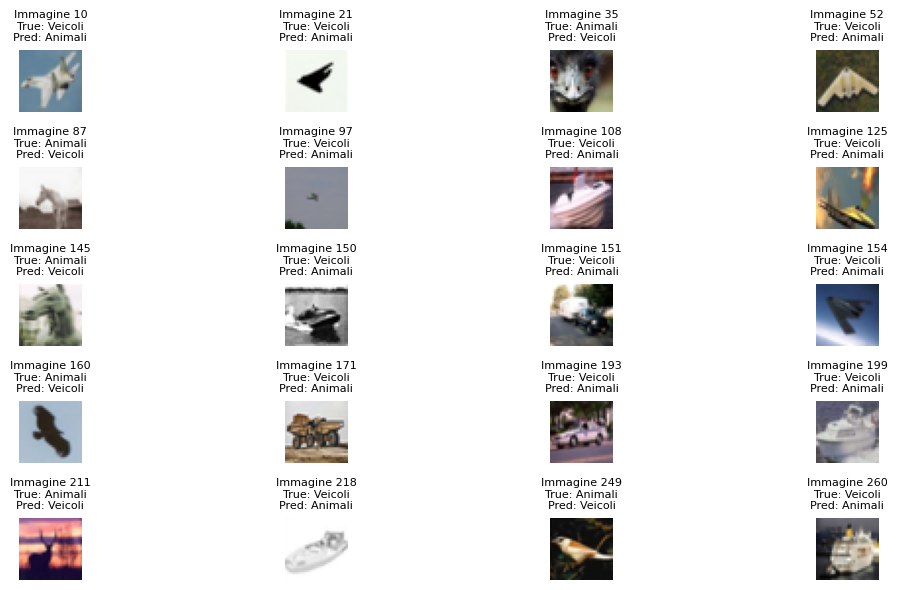

In [ ]:
errors2 = np.where(y_pred_transfer != y_true_transfer)[0]

print(f"Errori {len(errors2)} su {len(y_true_transfer)} immagini ({(len(errors2)*100)/len(y_true_transfer)}%)")
plot_errors(errors2, animals_binary_labels, X_test, y_true_transfer, y_pred_transfer)


La % di errori è maggiore del modello precedente. Anche immagini correttamente categorizzate dalla rete precedente in questa rete risultano errate.

##Conclusioni

La semplice rete CNN proposta seppure non contiene un numero di nodi molto elevato sembra apprendere bene da questo dataset e dà buoni risultati anche sul set di validazione attestandosi ad un accuracy del 94,6% e una LOSS di 0.1581 decisamente inferiore a quella del modello RESNET.
Il modello RESNET converge meglio sul training set, ma sul test set non riesce a raggiungere le stesse percentuali rimanendo con un accuracy finale in linea, con la rete precedente.

Data la complissità di questa ultima rete, io terrai il primo modello che dà anche tempi di predict inferiori(2ms/step cntro 6ms/step).
